In [129]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

In [130]:
for p in sys.path:
    print(p)

/home/vay3059/desktop/SURG-Mars/project/tests/actual
/opt/anaconda3/lib/python312.zip
/opt/anaconda3/lib/python3.12
/opt/anaconda3/lib/python3.12/lib-dynload

/home/vay3059/.local/lib/python3.12/site-packages
/opt/anaconda3/lib/python3.12/site-packages
/home/vay3059/desktop/SURG-Mars/project


In [131]:
stats = '../../data/peru_stations.txt'
df = pd.read_csv(stats, sep="|", header=0)
df

,Station,Source,Net,Latitude,Longitude,Distance,Azimuth,Elevation,Station Name
0,SJG,IRISDMC,IU,18.109100,-66.150000,33.243438,7.028308,420.0,"San Juan, Puerto Rico"
1,TGUH,IRISDMC,CU,14.057000,-87.273000,33.518785,-31.053157,1160.0,"Tegucigalpa, Honduras"
2,ANWB,IRISDMC,CU,17.668400,-61.785620,33.602282,14.586767,9.0,North Barbuda Island
3,SDDR,IRISDMC,CU,18.982121,-71.287836,33.893344,-1.850140,589.0,"Presa de Sabenta, Dominican Republic"
4,MTDJ,IRISDMC,CU,18.226050,-77.534540,33.900378,-12.562019,925.0,"Mount Denham, Jamaica"
5,RCBR,IRISDMC,IU,-5.827400,-35.901400,34.879419,78.589903,400.0,"Riachuelo, Brazil"
6,GTBY,IRISDMC,CU,19.926800,-75.110800,35.154672,-8.039822,79.2,"Guantanamo Bay, Cuba"
7,GRTK,IRISDMC,CU,21.511472,-71.134250,36.417286,-1.469043,13.0,"Grand Turk, Turks and Caicos Islands"
8,EFI,IRISDMC,II,-51.675300,-58.063700,38.043611,167.789711,110.0,"Mount Kent, East Falkland Island"
9,RPN,IRISDMC,II,-27.126700,-109.334400,38.342299,-115.105094,110.0,"Rapanui, Easter Island, Chile"


In [132]:
# select row from df where azimuth btn -172 and -169
df_selected = df[(df['Azimuth'] > -172) & (df['Azimuth'] < -169)]
df_selected

,Station,Source,Net,Latitude,Longitude,Distance,Azimuth,Elevation,Station Name
42,SBA,IRISDMC,IU,-77.849200,166.757200,81.931725,-169.735072,50.0,"Scott Base, Antarctica"
44,VNDA,IRISDMC,GT,-77.517275,161.852758,82.963574,-170.111378,121.1,"Dry Valley, Vanda, Antarctica"


In [133]:
data_path = '../../data/2022-05-26-mww72-central-peru'
files = [f for f in os.listdir(data_path) if f.endswith('.SAC')]
streams = [read(data_path + '/' + f) for f in files]
traces = [st[0] for st in streams if len(st) == 1]
assert len(traces) == len(files), "Some files contain more than one trace."
traces_dict = defaultdict(list)
for tr in traces:
    traces_dict[tr.stats.station].append(tr)
total_count = 0
for station in traces_dict:
    total_count += len(traces_dict[station])
    print(f'Station {station}, {traces_dict[station][0].stats.sac.dist: .2f} km, {len(traces_dict[station])} trace(s).')
print(f'Total traces: {total_count}')

Station SJG,  3673.31 km, 6 trace(s).
Station ANMO,  6709.74 km, 6 trace(s).
Station LBTB,  9886.89 km, 3 trace(s).
Station ASCN,  6121.35 km, 6 trace(s).
Station SHEL,  6883.49 km, 6 trace(s).
Station SBA,  9125.49 km, 6 trace(s).
Station TUC,  6774.96 km, 9 trace(s).
Station BBSR,  5258.27 km, 6 trace(s).
Station TX31,  6067.57 km, 3 trace(s).
Station TSUM,  9247.88 km, 6 trace(s).
Station PASC,  7429.21 km, 6 trace(s).
Station FFC,  8274.03 km, 6 trace(s).
Station COR,  8489.05 km, 9 trace(s).
Station PMSA,  5560.09 km, 6 trace(s).
Station SSPA,  6193.82 km, 6 trace(s).
Station RAR,  9378.23 km, 6 trace(s).
Station PAB,  9087.07 km, 6 trace(s).
Station SFJD,  9220.56 km, 6 trace(s).
Station EFI,  4220.76 km, 6 trace(s).
Station ESK,  9966.12 km, 6 trace(s).
Station RCBR,  3877.46 km, 6 trace(s).
Station HOPE,  5256.33 km, 6 trace(s).
Station SACV,  6091.87 km, 6 trace(s).
Station HKT,  5669.75 km, 6 trace(s).
Station PTCN,  6316.99 km, 6 trace(s).
Station CCM,  6254.88 km, 6 trace(s

In [134]:
name = 'TX31'
sta = traces_dict[name]

locs = {tr.stats.location for tr in sta}
print(locs)

loc = '00'
if len(sta) > 3:
    sta = [tr for tr in sta if tr.stats.location == loc]

sta[0].stats

{''}


         network: IM
         station: TX31
        location: 
         channel: BHN
       starttime: 2022-05-26T12:06:26.000000Z
         endtime: 2022-05-26T12:20:47.000000Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 34441
           calib: 2537550000.0
         _format: SAC
             sac: AttribDict({'delta': 0.025, 'scale': 2537550000.0, 'b': 0.0, 'e': 861.0, 'o': -243.0, 'stla': 29.3343, 'stlo': -103.6677, 'stel': 991.4, 'stdp': 0.0, 'evla': -14.8942, 'evlo': -70.1969, 'evdp': 252.0, 'dist': 6067.573, 'az': 323.7712, 'baz': 139.12581, 'gcarc': 54.569412, 'cmpaz': 0.0, 'cmpinc': 90.0, 'nzyear': 2022, 'nzjday': 146, 'nzhour': 12, 'nzmin': 6, 'nzsec': 26, 'nzmsec': 0, 'nvhdr': 6, 'npts': 34441, 'iftype': 1, 'leven': 1, 'kstnm': 'TX31', 'kevnm': 'CentralPeru', 'kcmpnm': 'BHN', 'knetwk': 'IM', 'kinst': 'CMG3T_BR'})

In [135]:
net = df.loc[df["Station"] == name, "Net"].iloc[0]
print(name, net)

TX31 IM


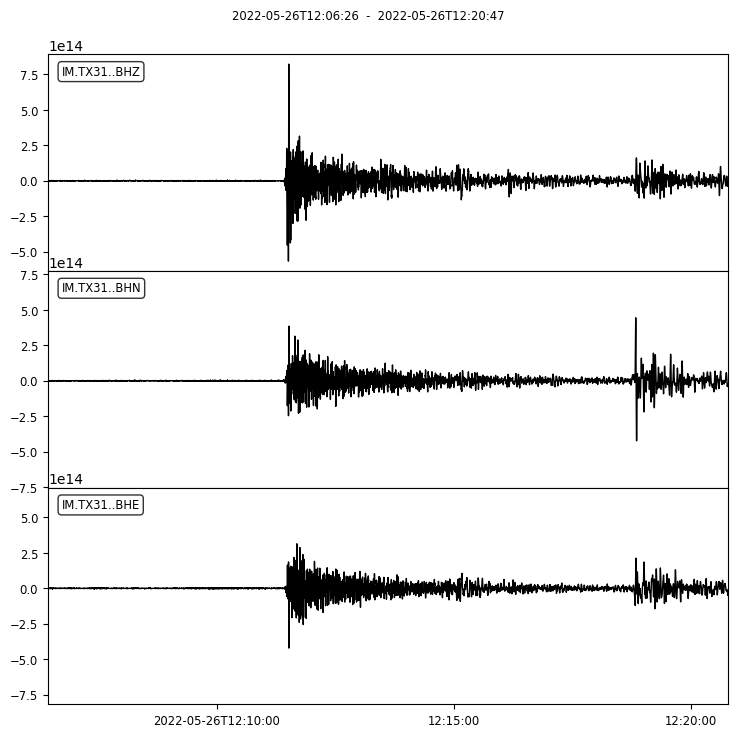

In [136]:
st = Stream(sta)
st.plot();

In [137]:
client = Client("IRIS")
starttime = st[0].stats.starttime
endtime = st[0].stats.endtime
inv = client.get_stations(network=net, station=name,
                          starttime=starttime, endtime=endtime,
                          level='response')

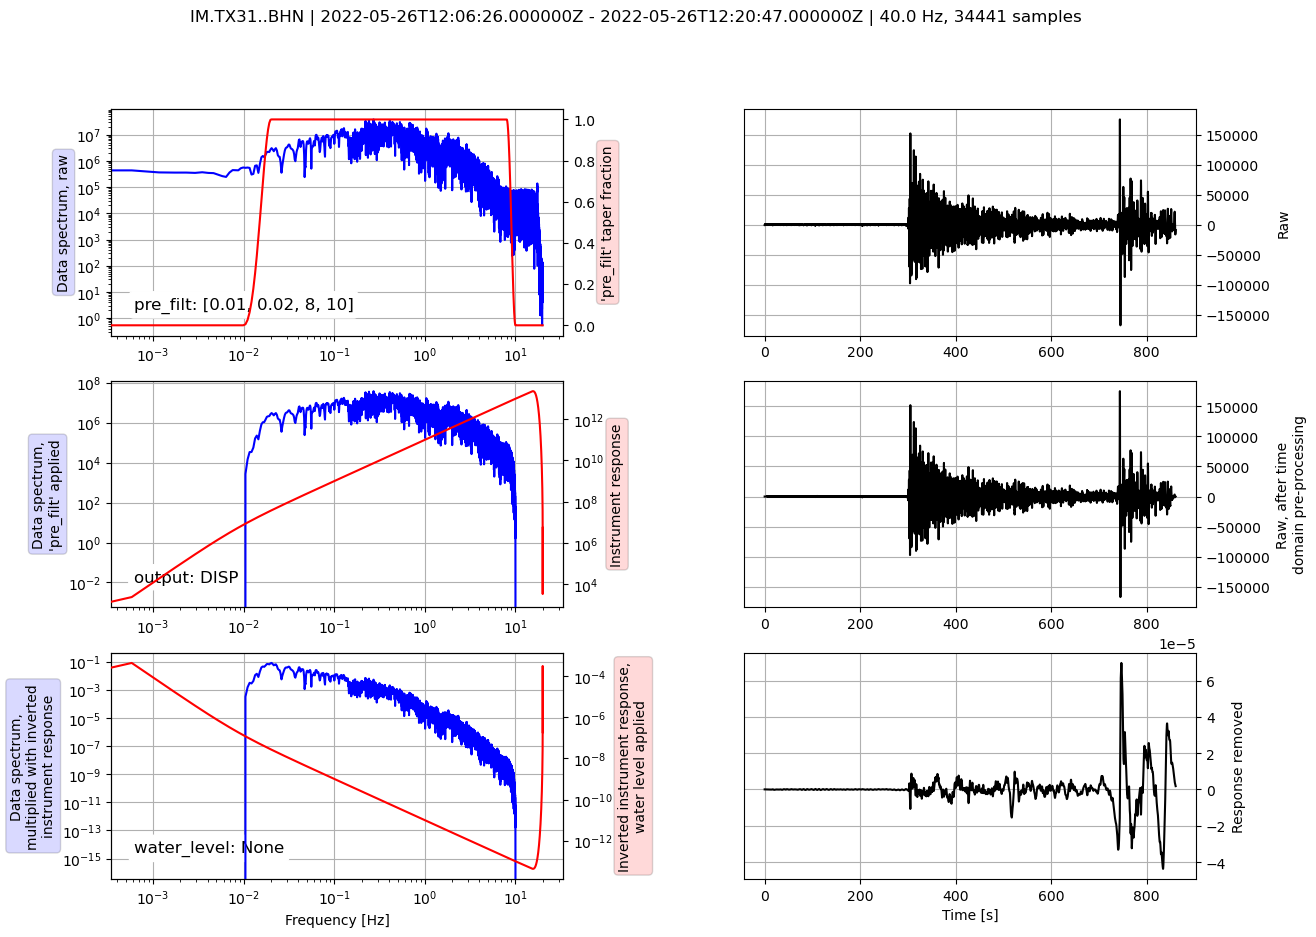

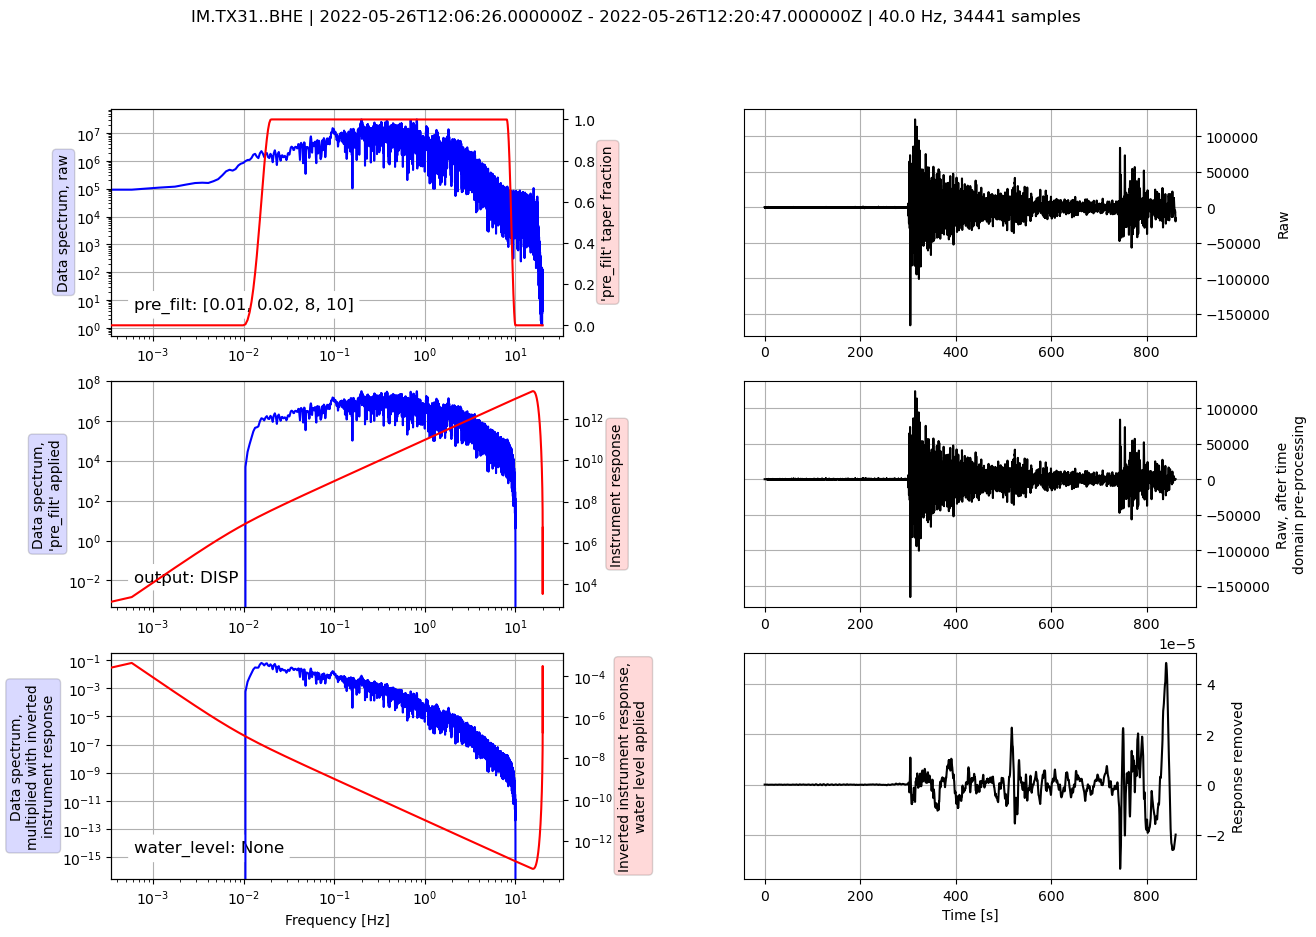

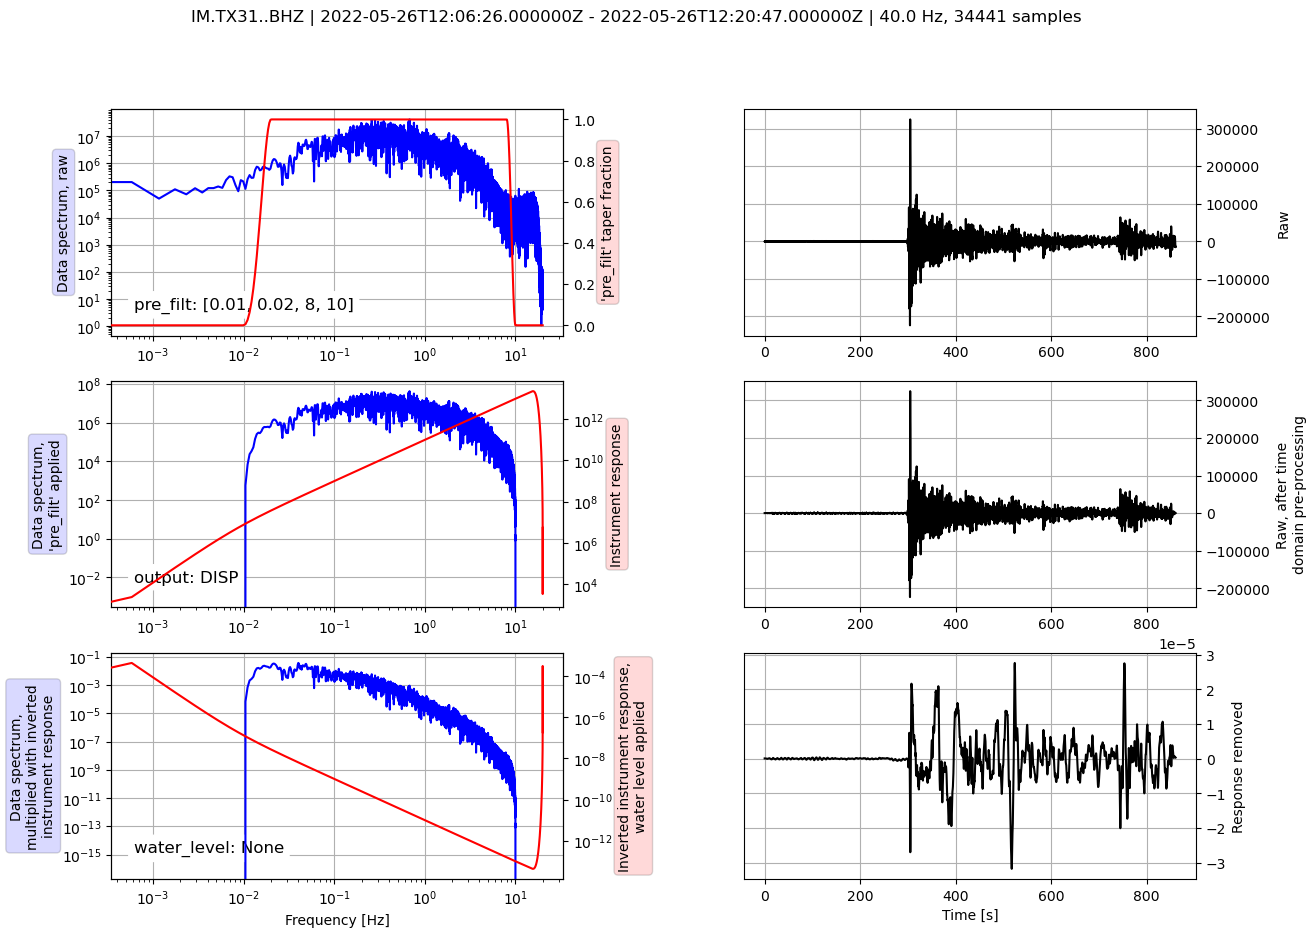

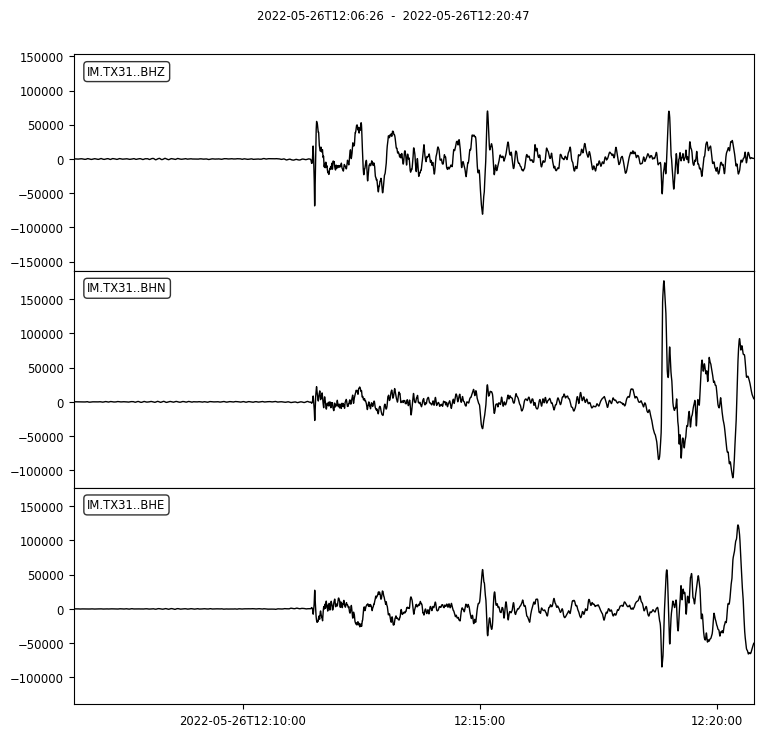

In [138]:
pre_filt = (0.01, 0.02, 8.0, 10.0)
for tr in st:
    tr.remove_response(inventory=inv, output="DISP", pre_filt=pre_filt,
                       plot=True, water_level=None)
st.plot();

In [139]:
# Date-Time (UTC): 	2022-05-26 12:02:30
# Location: 	CENTRAL PERU
# Latitude, Longitude: 	-14.790 °, -70.260 °
# Magnitude: 	7.2 MW
# Depth: 	234.4 km
# Author: 	Global CMT Project
# Catalog, Contributor: 	GCMT, GCMT

eq_lat = -14.790
eq_lon = -70.260
hdepth = 584.3  # depth in km

In [140]:
velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

At depth 584.3 km, P velocity = 9.945648 km/s, S velocity = 5.4503188 km/s


In [141]:
print(f'Earthquake coordinates: lat {eq_lat}, lon {eq_lon}')
sta_lat = sta[0].stats.sac.stla
sta_lon = sta[0].stats.sac.stlo
print(f'Station coordinates: lat {sta_lat:.2f}, lon {sta_lon:.2f}')
event_locs = [eq_lat, eq_lon, sta_lat, sta_lon]
dist, az_check, baz_check = gps2dist_azimuth(*event_locs)
epdist = kilometers2degrees(dist/1000)
print(f'Distance between event and station: {dist/1000:.2f} km, {epdist:.2f} degrees')
print(f'Azimuth: {az_check:.2f}, Back-azimuth: {baz_check:.2f}')

az = st[0].stats.sac.az
baz = st[0].stats.sac.baz
print(f'Original azimuth: {az:.2f}, back-azimuth: {baz:.2f}')

Earthquake coordinates: lat -14.79, lon -70.26
Station coordinates: lat 29.33, lon -103.67
Distance between event and station: 6060.04 km, 54.50 degrees
Azimuth: 323.78, Back-azimuth: 139.08
Original azimuth: 323.77, back-azimuth: 139.13


In [142]:
p_arrival = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist, phase_list=['P'])[0]
s_arrival = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                    distance_in_degree=epdist, phase_list=['S'])[0]

# print out other travel times for information
# use the default phase list

p_inc = p_arrival.incident_angle
s_inc = s_arrival.incident_angle
print(f'Incidence angles: P = {p_inc:.2f}, S = {s_inc:.2f}')

Incidence angles: P = 21.35, S = 23.91


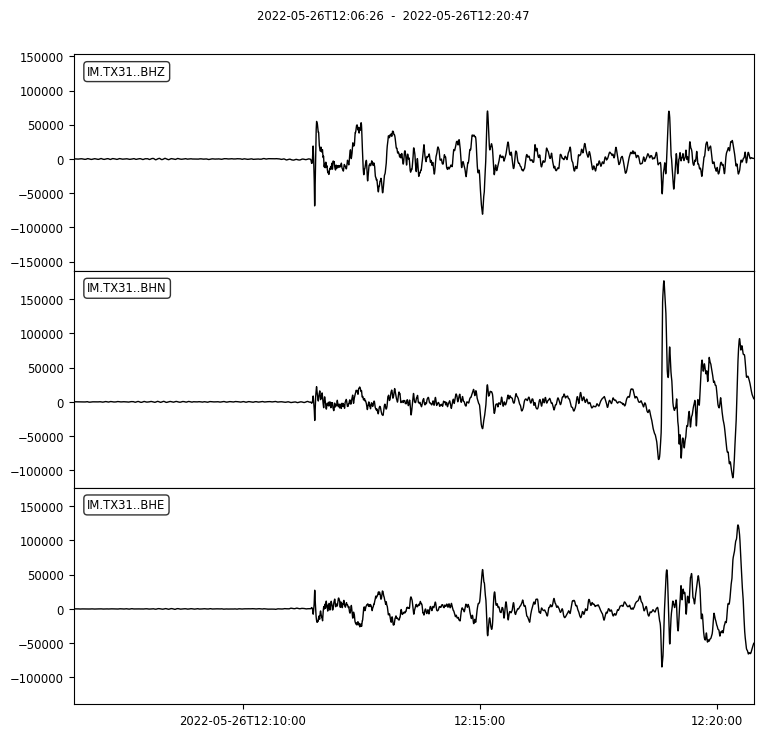

In [143]:
st._rotate_to_zne(inventory=inv)
st.plot();

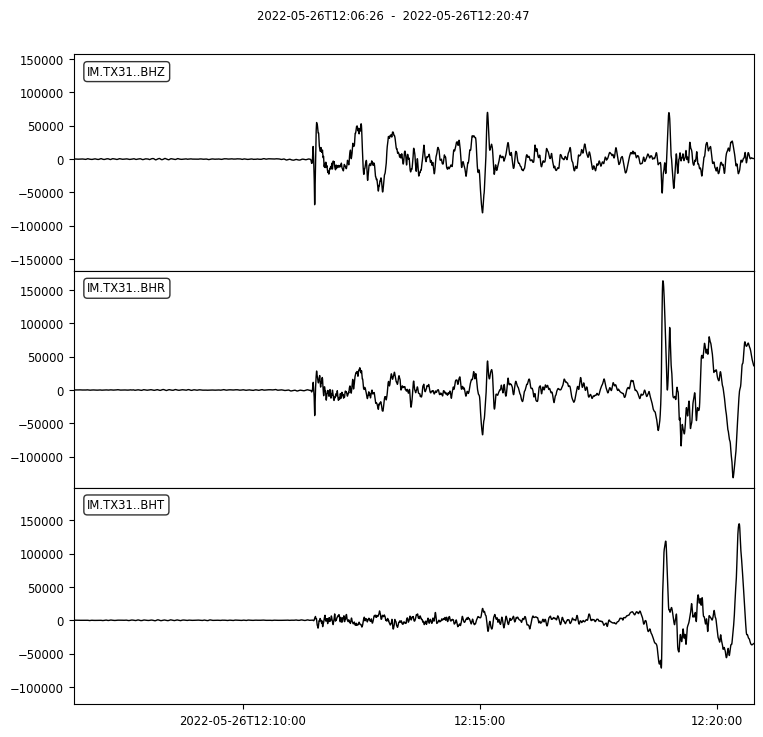

In [144]:
st_RT = st.copy()
st_RT.rotate('NE->RT', back_azimuth=baz)
st_RT.plot();

In [145]:
st_P = st.copy()
st_P.rotate('ZNE->LQT', back_azimuth=baz, inclination=p_inc)
st_S = st.copy()
st_S.rotate('ZNE->LQT', back_azimuth=baz, inclination=s_inc)

p_init, s_fin = st_P[0].stats.starttime, st_S[0].stats.endtime
p_arrival = p_init + 300  # 2 minutes after start
s_arrival = s_fin - 120  # 5 minutes before end

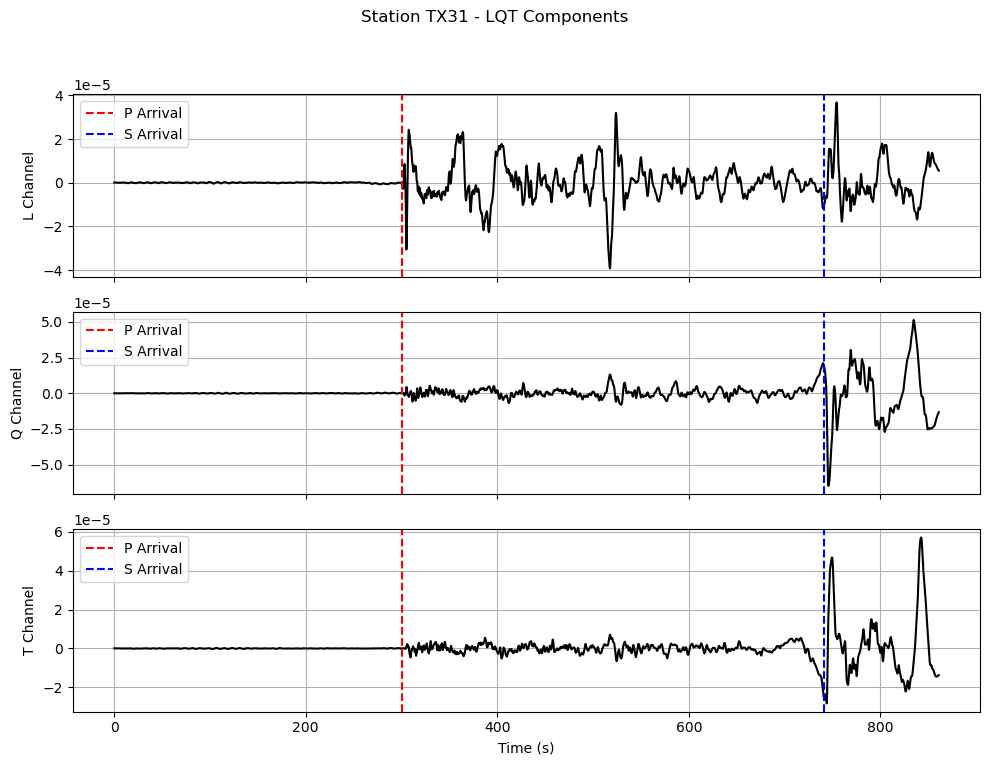

In [146]:
# make subplots of all three components L, Q, T
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True)
components = ['L', 'Q', 'T']
for i, comp in enumerate(components):
    tr = st_P.select(component=comp)[0]
    times = tr.times(type='relative')
    axes[i].plot(times, tr.data, 'k')
    axes[i].set_ylabel(f'{comp} Channel')
    axes[i].grid()
    axes[i].axvline(p_arrival-p_init, color='r', linestyle='--', label='P Arrival')
    axes[i].axvline(s_arrival-p_init, color='b', linestyle='--', label='S Arrival')
    axes[i].legend()

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Station {name} - LQT Components')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [147]:
# overlayed plot of channels at p-arrival
tr_P = st_P.select(component='L')[0].copy()
tr_Sv = st_P.select(component='Q')[0].copy()
tr_Sv.data = -tr_Sv.data
tr_Sh = st_P.select(component='T')[0].copy()

p_start = p_arrival - 120
p_end = p_arrival + 80
tr_P = tr_P.slice(p_start, p_end)
tr_Sv = tr_Sv.slice(p_start, p_end)
tr_Sh = tr_Sh.slice(p_start, p_end)

In [148]:
# overlayed plot of channels at s-arrival
tr2_P = st_S.select(component='L')[0].copy()
tr2_Sv = st_S.select(component='Q')[0].copy()
tr2_Sv.data = -tr2_Sv.data
tr2_Sh = st_S.select(component='T')[0].copy()

s_arrival = tr2_Sv.stats.endtime - 120  # 2 minutes before end
s_start = s_arrival - 120
s_end = s_arrival + 80
tr2_P = tr2_P.slice(s_start, s_end)
tr2_Sv = tr2_Sv.slice(s_start, s_end)
tr2_Sh = tr2_Sh.slice(s_start, s_end)

In [149]:
# now gather the data as a 3D matrix
data = np.zeros((len(st), len(st[0].data)))
data.shape

# get the individual traces first
tr_ZL = st.select(component='Z')[0].copy()
tr_NQ = st.select(component='N')[0].copy()
tr_ET = st.select(component='E')[0].copy()

# then preprocess them
for tr in [tr_ZL, tr_NQ, tr_ET]:
    tr.detrend('linear')
    tr.detrend('demean')
    tr.filter('lowpass', freq=.08,
              corners=4, zerophase=True)

# then fill the data matrix
data[0, :] = tr_ZL.data
data[1, :] = tr_NQ.data
data[2, :] = tr_ET.data

# get azimuth, p and s incidence angles
my_az = (baz - 180) % 360
my_p_inc = p_inc
my_s_inc = s_inc

# matrix rotation ZNE -> ZRT
importlib.reload(fn)
R_zne2zrt = fn.zne2zrt_matrix(my_az, deg=True)
R_zne2lqt = fn.zrt2lqt_matrix(p_inc=my_p_inc, s_inc=my_s_inc, deg=True)
data_zrt = R_zne2zrt @ data
data_lqt = R_zne2lqt @ data_zrt

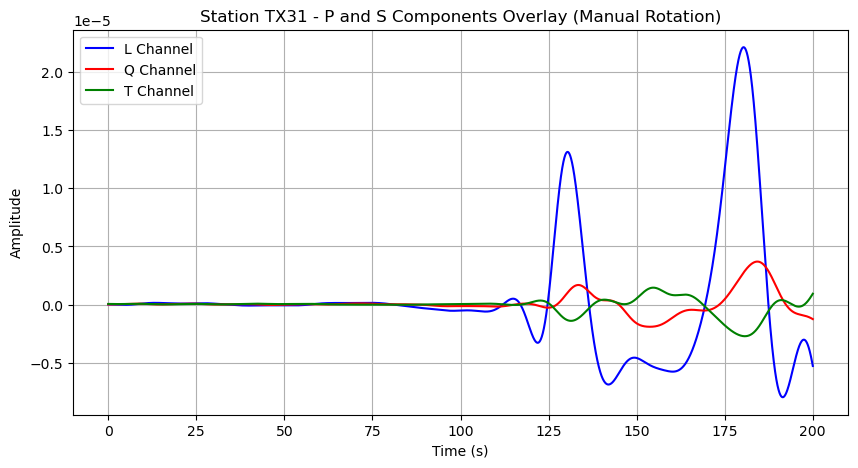

In [150]:
# using p_start and p_end to slice the data_lqt matrix
# use p init, sampling rate and delta to get indices
delta = st[0].stats.delta

# use p_init as starting time
p_start_idx = int((p_start - p_init) / delta)
p_end_idx = int((p_end - p_init) / delta)
sliced_data_p = data_lqt[:, p_start_idx:p_end_idx+1]

# overlayed plot of channels at p-arrival
fig, ax = plt.subplots(figsize=(10, 5))
sliced_times_p = np.arange(sliced_data_p.shape[1]) * delta # + (p_start - p_init)
ax.plot(sliced_times_p, sliced_data_p[0, :], 'b', label='L Channel')
ax.plot(sliced_times_p, sliced_data_p[1, :], 'r', label='Q Channel')
ax.plot(sliced_times_p, sliced_data_p[2, :], 'g', label='T Channel')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - P and S Components Overlay (Manual Rotation)')
ax.legend()
ax.grid()
plt.show()

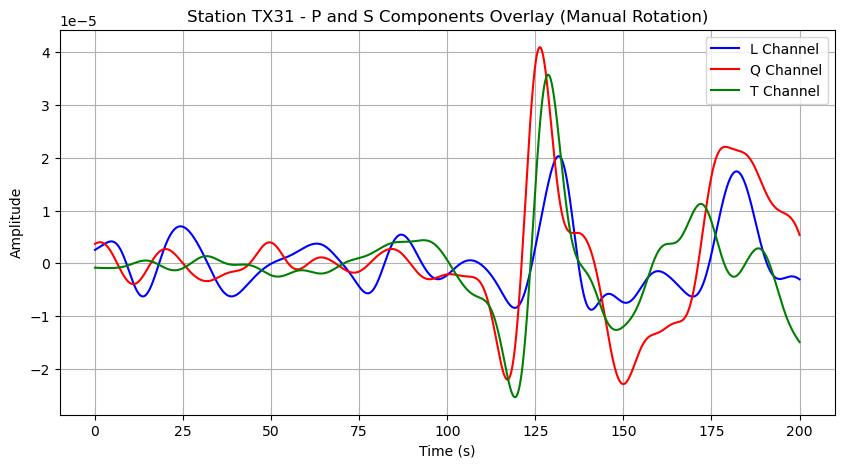

In [151]:
# same processing for s-arrival
s_start_idx = int((s_start - p_init) / delta)
s_end_idx = int((s_end - p_init) / delta)
sliced_data_s = data_lqt[:, s_start_idx:s_end_idx+1]

# overlayed plot of channels at s-arrival
fig, ax = plt.subplots(figsize=(10, 5))
sliced_times_s = np.arange(sliced_data_s.shape[1]) * delta # + (s_start - p_init)
ax.plot(sliced_times_s, sliced_data_s[0, :], 'b', label='L Channel')
ax.plot(sliced_times_s, sliced_data_s[1, :], 'r', label='Q Channel')
ax.plot(sliced_times_s, sliced_data_s[2, :], 'g', label='T Channel')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - P and S Components Overlay (Manual Rotation)')
ax.legend()
ax.grid()
plt.show()

### COLLECTING AMPLITUDES

In [152]:
# get window to identify arrivals
p_pick = 125 # TODO: estimated time

# get index where sliced data = p_pick
p_index = int(p_pick / delta)

half_window = int(10 / delta)  # TODO: num sec on each side

zoomed_data_p = sliced_data_p[:,p_index-half_window:p_index+half_window+1]

# get from index plus minus 5 seconds
p_slice_idx = p_index - half_window + np.argmax(zoomed_data_p[0, :])
p_amp = sliced_data_p[0, p_slice_idx]
p_pick_real = sliced_times_p[p_slice_idx]

# same for s-arrival
s_pick = 125 # TODO: estimated time
s_index = int(s_pick / delta)

zoomed_data_s = sliced_data_s[:,s_index-half_window:s_index+half_window+1]

sv_slice_idx = s_index - half_window + np.argmax(zoomed_data_s[1, :])
sv_amp = sliced_data_s[1, sv_slice_idx]
sv_pick_real = sliced_times_s[sv_slice_idx]

sh_slice_idx = s_index - half_window + np.argmax(zoomed_data_s[2, :])
sh_amp = sliced_data_s[2, sh_slice_idx]
sh_pick_real = sliced_times_s[sh_slice_idx]

p_amp, sv_amp, sh_amp

(1.3129954490380167e-05, 4.094363065868677e-05, 3.5745360711624955e-05)

In [153]:
model_Ao = fn.unit_vec(np.array([-0.0501, -0.399 , -0.9156]))
real_Ao = fn.unit_vec(np.array([p_amp, sv_amp, sh_amp]))
cossim = fn.unit_vec(model_Ao) @ fn.unit_vec(real_Ao)
print(f'Cossim: {cossim:.4f}')
print(f'Model Ao: {model_Ao}\nReal Ao: {real_Ao}')

Cossim: -0.8892
Model Ao: [-0.0501 -0.399  -0.9156]
Real Ao: [0.2348 0.7322 0.6393]


### COLLECTING UNCERTAINTIES

In [154]:
# get uncertainties from the previous datapoints
p_unc_pick = 110
p_unc_index = int(p_unc_pick / delta)

s_unc_pick = 110
s_unc_index = int(s_unc_pick / delta)

p_std = np.std(sliced_data_p[0, :p_unc_index])
sv_std = np.std(sliced_data_s[1, :s_unc_index])
sh_std = np.std(sliced_data_s[2, :s_unc_index])
p_std, sv_std, sh_std

(2.255153195586681e-07, 2.17222084774642e-06, 2.322605753755793e-06)

#### NICE PLOTS

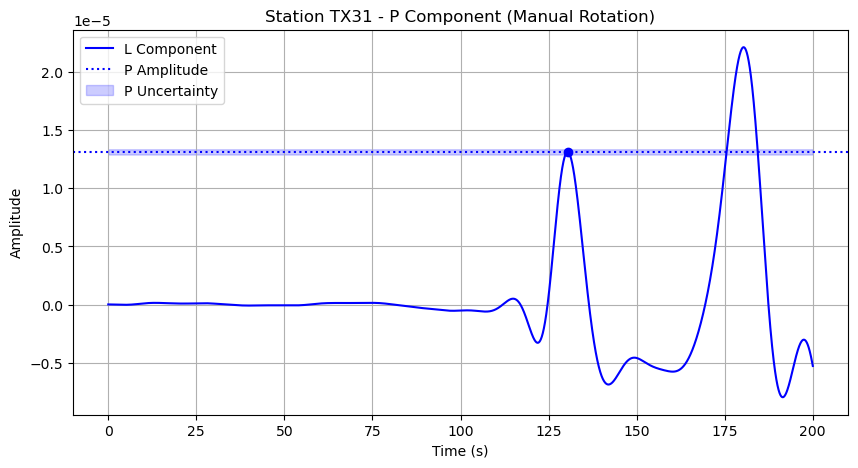

In [155]:
# single plot of channels at p-arrival
fig, ax = plt.subplots(figsize=(10, 5))
sliced_times_p = np.arange(sliced_data_p.shape[1]) * delta # + (p_start - p_init)
ax.plot(sliced_times_p, sliced_data_p[0, :], 'b', label='L Component')
ax.axhline(p_amp, color='b', linestyle=':', label='P Amplitude')
ax.plot(p_pick_real, p_amp, 'bo')

plt.fill_between(sliced_times_p, p_amp-p_std, p_amp+p_std, color='b', alpha=0.2, label='P Uncertainty')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - P Component (Manual Rotation)')
ax.legend()
ax.grid()
plt.show()

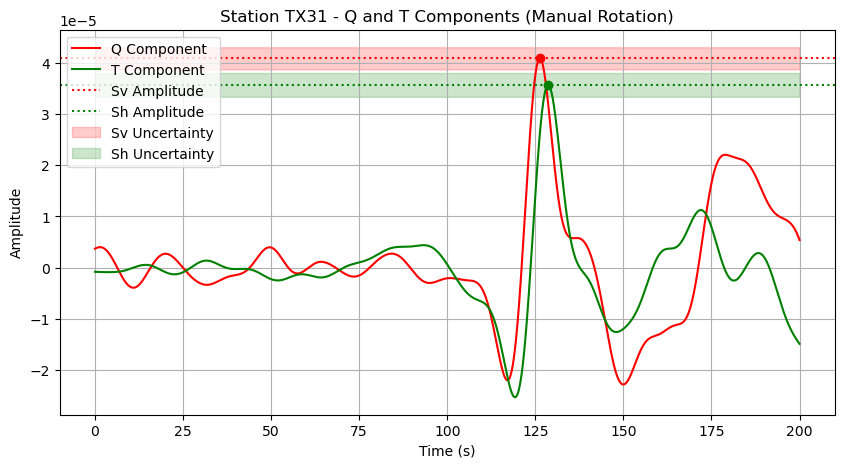

In [156]:
# q and t components at s-arrival
fig, ax = plt.subplots(figsize=(10, 5))
sliced_times_s = np.arange(sliced_data_s.shape[1]) * delta # +
ax.plot(sliced_times_s, sliced_data_s[1, :], 'r', label='Q Component')
ax.plot(sliced_times_s, sliced_data_s[2, :], 'g', label='T Component')
ax.axhline(sv_amp, color='r', linestyle=':', label='Sv Amplitude')
ax.plot(sv_pick_real, sv_amp, 'ro')
ax.axhline(sh_amp, color='g', linestyle=':', label='Sh Amplitude')
ax.plot(sh_pick_real, sh_amp, 'go')

plt.fill_between(sliced_times_s, sv_amp-sv_std, sv_amp+sv_std, color='r',
                    alpha=0.2, label='Sv Uncertainty')
plt.fill_between(sliced_times_s, sh_amp-sh_std, sh_amp+sh_std, color='g',
                    alpha=0.2, label='Sh Uncertainty')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - Q and T Components (Manual Rotation)')
ax.legend()
ax.grid()
plt.show()

### STATION LOCATION 1

In [157]:
# set up hyperparameters for inversion
epdist_1 = epdist  # degrees - epicentral distance
azimuth_1 = az # degrees - azimuth of seismometer
hdepth_1 = hdepth

p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth_1,
                        distance_in_degree=epdist_1, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth_1,
                        distance_in_degree=epdist_1, phase_list=['S'])
takeoff_angles = [p_arrivals[0].takeoff_angle, s_arrivals[0].takeoff_angle]
print(f'Takeoff angles are {takeoff_angles}')
velocities = fn.extract_velocities(lookup_table, hdepth_1)

# initialize model
radiation_model_1 = rm.RadiationModel(np.deg2rad(azimuth_1), takeoff_angles,
                                      velocities)

# # TODO: use the theoretical amplitudes as comparison
# model_Ao = radiation_model_1(np.deg2rad(true_params), set_Ao=True, return_A=True)
observed_Ao = np.array([p_amp, sv_amp, sh_amp])
radiation_model_1.set_Ao(observed_Ao)

# TODO: set uncertainties
observed_unc = np.array([p_std, sv_std, sh_std])
radiation_model_1.set_Uo(observed_unc)

# TODO: set benckmark
benchmark = (np.array([360, 20, -64]), np.array([152, 72, -99]))
radiation_model_1.set_real_sdr(np.deg2rad(benchmark[0]))

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts = 50
starts = fn.random_params(num_starts)

radiation_model_1.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_1, config, start)

print(f'Convergence rate: {radiation_model_1.get_convergence_rate():.0f}%')

Takeoff angles are [43.40706870976866, 44.65446553632773]
Using sdr parameters.
Run 0 of 50


Run 10 of 50
Run 20 of 50
Run 30 of 50
Run 40 of 50
Convergence rate: 94%


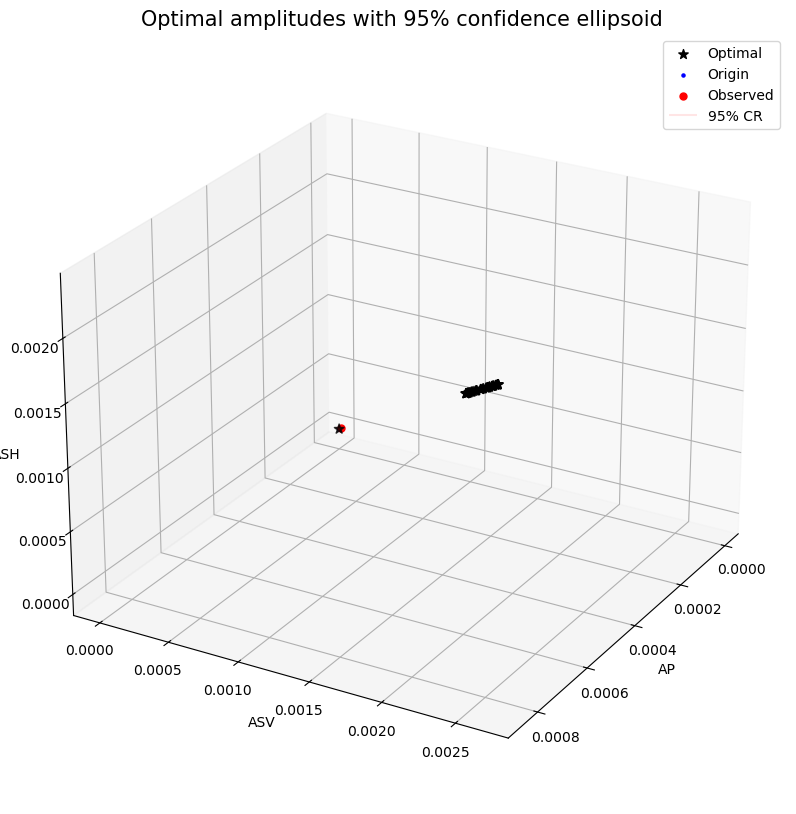

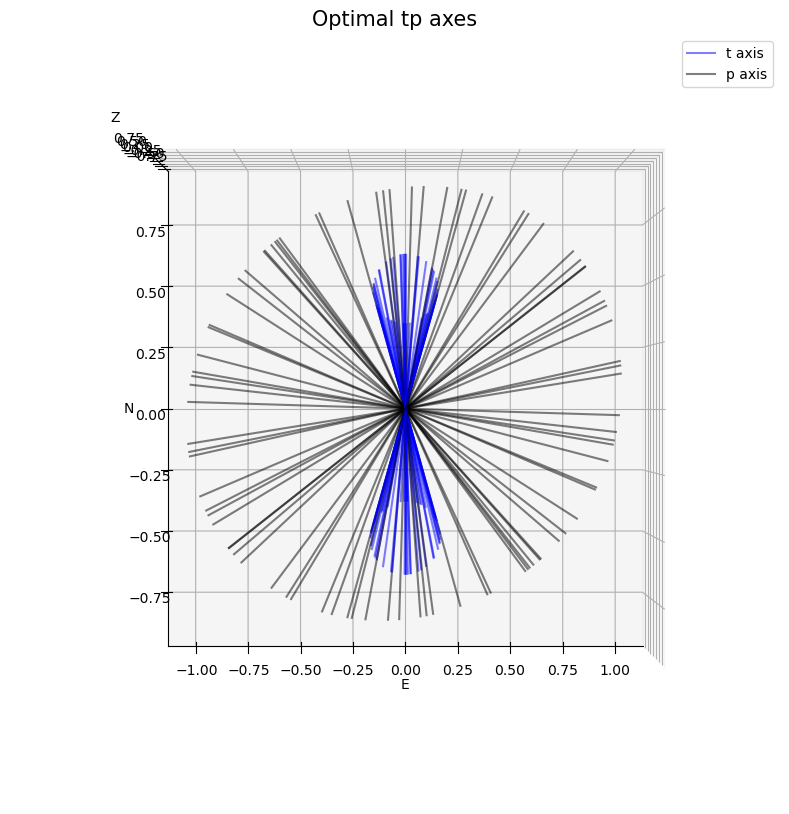

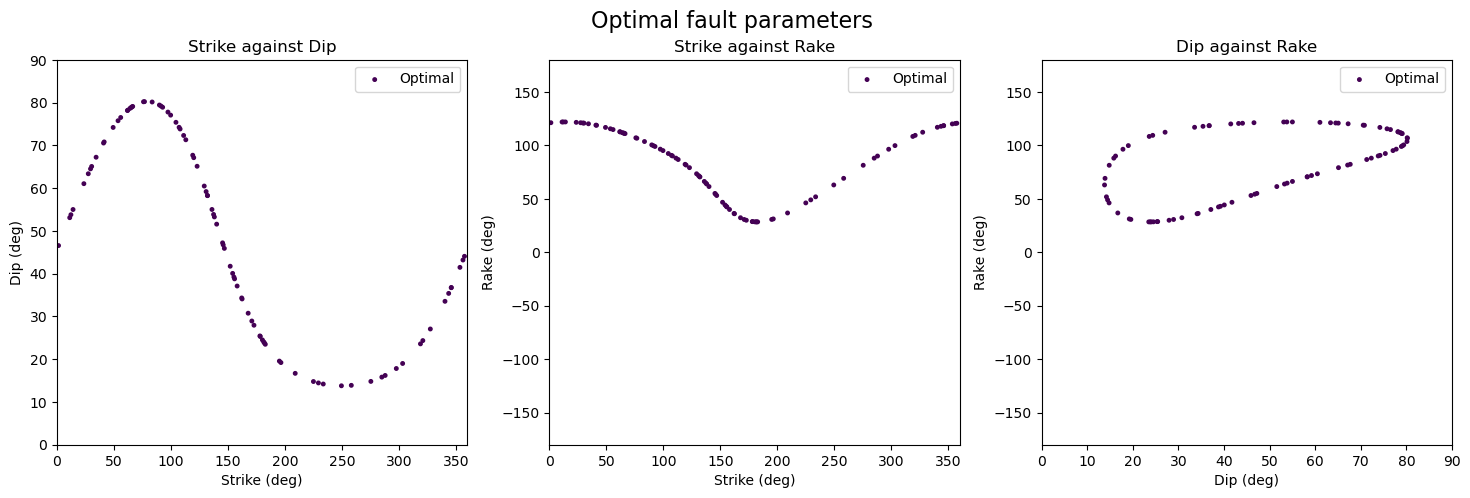

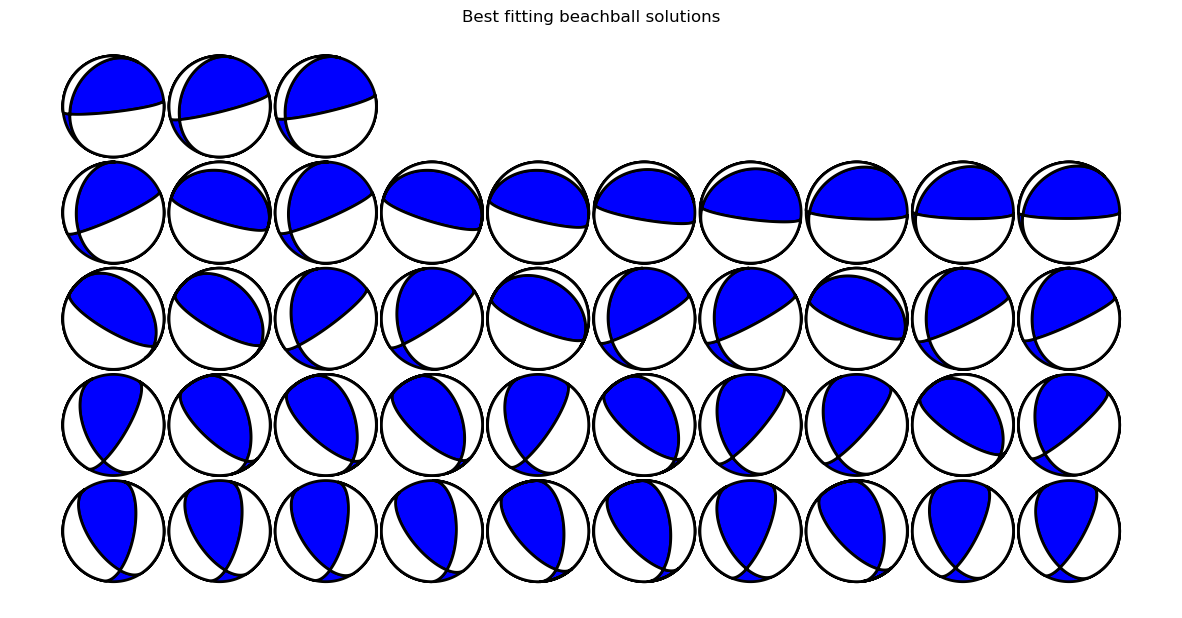

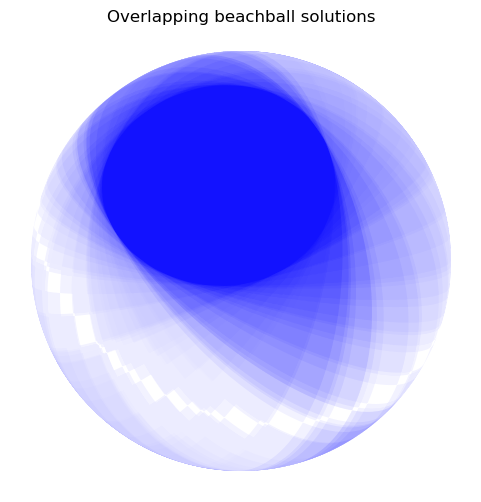

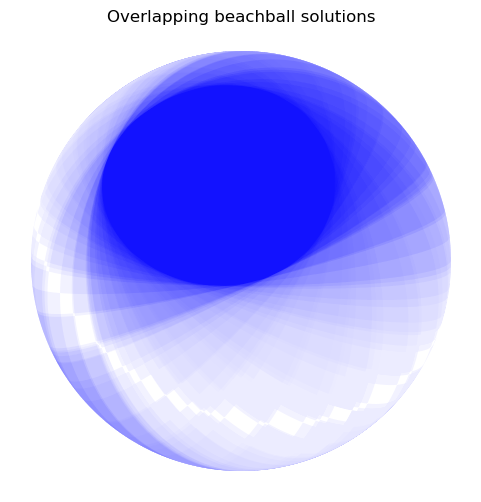

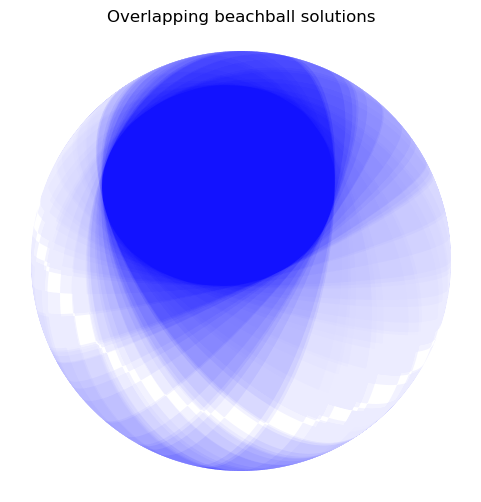

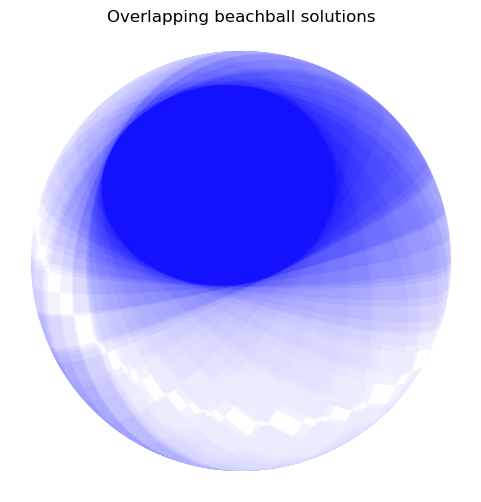

In [158]:
# amplitude plot
radiation_model_1.reset_grid_amplitudes()
radiation_model_1.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_1, azim=30, elev=25, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_1, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis')

# beachball plots
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=False)

# overlapping beachball plot
plots.beachballs(radiation_model_1, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=False)
plots.beachballs(radiation_model_1, order_by='dip', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=False)
plots.beachballs(radiation_model_1, order_by='rake', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=False)
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=False)

#### COMPARE: https://ds.iris.edu/spud/momenttensor/941680

[145.2563  47.1902  54.9746] [ 11.1404  53.0761 121.7817]
67.34299374987768


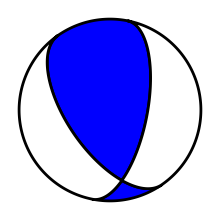

[145.8082  46.7259  54.2735] [ 12.1859  53.7672 121.8072]
67.39520916040209


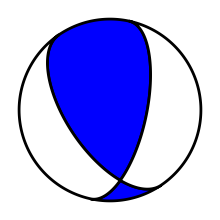

[146.806   45.9001  53.0318] [ 14.0503  54.987  121.8224]
67.55966528460694


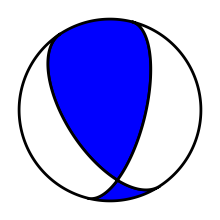

In [159]:
opt_iterates = radiation_model_1.get_optimal_iterates()
kagan_angles = radiation_model_1.get_kagan_angles()

for idx, item in enumerate(opt_iterates[:3]):
    t1, p1 = fn.sdr2tp(item)
    sdr1, sdr2 = fn.tp2sdr(t1, p1, True)
    print(sdr1, sdr2)
    print(np.rad2deg(kagan_angles[idx]))
    fn.beachball(sdr1)

In [160]:
# plots with uncertainty
# TODO: debug the uncertainty plots. compare with synthetic tests

# plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# plots.beachballs(radiation_model_1, order_by='strike', width=10,  max_plot=50,
#                  original=True, figsize=(15,10), overlap=False, uncertainty=False)